# Optimal number of clusters

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data ingestion

In [2]:
def load_xai_arrs(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Clustering

In [4]:
def plot_inertias_silhouettes(
    inertias,
    silhouettes,
    n_clusters,
    subtitle="",
):
    fig, axs = plt.subplots(2, 1, figsize=None, sharex=True)
    axs[0].plot(range(2, n_clusters), inertias, "-o")
    axs[1].plot(range(2, n_clusters), silhouette_scores, "-o")

    # Add major and minor ticks
    for ax in axs:
        # major ticks every 2
        ax.xaxis.set_major_locator(ticker.MultipleLocator(4))
        # minor ticks every 1
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
        ax.grid(True, which="major", linestyle="--", alpha=0.7)
        ax.grid(True, which="minor", linestyle=":", alpha=0.4)
    # Add labels
    axs[0].set_ylabel("Inertia")
    axs[1].set_ylabel("Silhouette Score")
    x_ticks = range(0, n_clusters + 2)
    axs[1].set_xticks(x_ticks)
    # Shared x-label and title
    fig.supxlabel("Number of Clusters")
    fig.suptitle("Clustering Metrics vs Number of Clusters\n" f"{subtitle}")

    return fig, axs

## PCA

In [5]:
def pca_variance_analysis(X: np.ndarray, variance_threshold: float = 0.95):
    """
    Performs PCA on the input matrix and determines the number of components
    required to retain a specified amount of variance.

    Parameters
    ----------
    X : np.ndarray
        Input data matrix of shape (n_samples, n_features).
    variance_threshold : float
        The target cumulative explained variance (default is 0.95).

    Returns
    -------
    n_components_needed : int
        Number of PCA components needed to explain the desired variance.
    explained_variance_ratio : np.ndarray
        Cumulative explained variance ratio for each principal component.
    X_pca : np.ndarray
        Data projected into the PCA space (all components).
    """
    pca = PCA()
    X_pca = pca.fit_transform(X)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components_needed = np.searchsorted(cumulative_variance, variance_threshold) + 1

    return n_components_needed, cumulative_variance, X_pca

In [6]:
def plot_pca_variance(
    cumulative_variance,
    n_components_needed,
    variance_threshold=0.95,
    figsize=(10, 6),
):
    """
    Plots the cumulative explained variance ratio from PCA.

    Parameters
    ----------
    cumulative_variance : np.ndarray
        Cumulative explained variance ratio for each principal component.
    n_components_needed : int
        Number of PCA components needed to explain the desired variance.
    variance_threshold : float
        The target cumulative explained variance (default is 0.95).
    """

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(cumulative_variance, marker="o", linestyle="--")

    ax.axhline(
        y=variance_threshold,
        color="r",
        linestyle="--",
        label=f"{variance_threshold:.0%} Variance Threshold",
    )

    ax.axvline(
        x=n_components_needed,
        color="g",
        linestyle="--",
        label=f"Components Needed: {n_components_needed}",
    )

    ax.set_title("PCA Cumulative Explained Variance")
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Cumulative Explained Variance Ratio")
    ax.legend()
    ax.grid()
    plt.tight_layout()
    return fig, ax

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

## Data

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"
latent_arr = np.load(f"{latent_dir}/{bin_id}/latent_{bin_id}.npy", mmap_mode="r")

# SE

## Data prep

In [9]:
score_name = "mse"

run_ids_se_dict = {
    "110": "xai_202606230008_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606230036_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606230118_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

se_anomalies_arr, se_specobjids_array, se_weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_se_dict, load_from=load_from
)

se_110_dict = weights_prep(weights=se_weights_dict["110"], n_segments=110)
se_150_dict = weights_prep(weights=se_weights_dict["150"], n_segments=150)
se_221_dict = weights_prep(weights=se_weights_dict["221"], n_segments=221)

Base size: 34, Residual size: 33
New number of segments: 111
Base size: 25, Residual size: 23
New number of segments: 151
Base size: 17, Residual size: 16
New number of segments: 222


## Clustering 150

Run time: 3.54 seconds


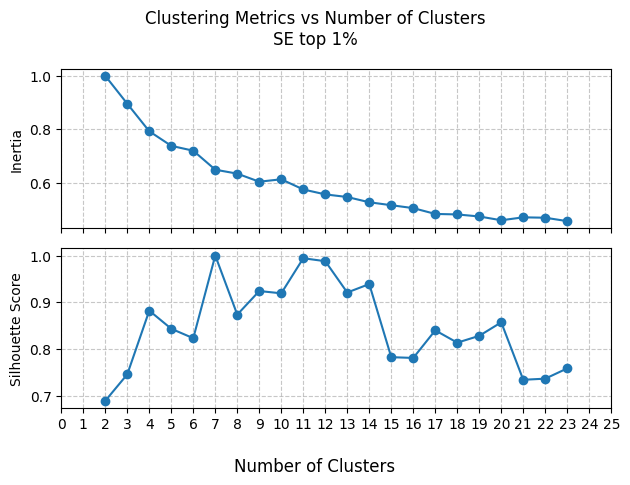

In [10]:
n_clusters = 24
n_top = se_150_dict["weights"].shape[0]
X = se_150_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
se_150_dict["inertias"] = inertias
se_150_dict["silhouette"] = silhouette_scores

subptitle = "SE top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=se_150_dict["inertias"],
    silhouettes=se_150_dict["silhouette"],
    n_clusters=se_150_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse/clustering_150_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse/clustering_150_metrics.jpg")

### PCA

Number of components needed to explain  95.0% variance: 52


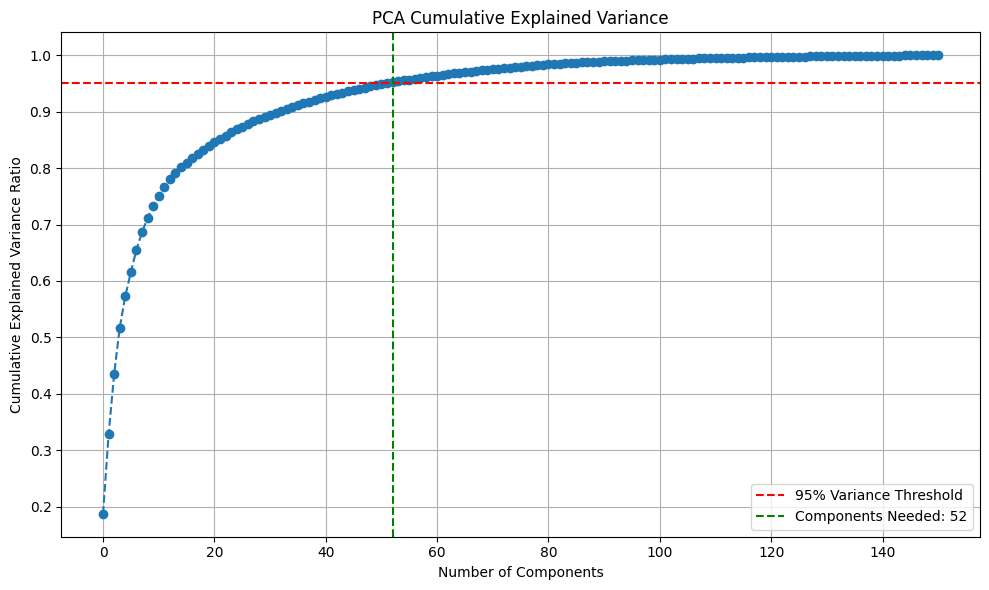

In [12]:
X = se_150_dict["norm_unique_weights"]

variance_threshold = 0.95
n_components, cumvar, X_pca = pca_variance_analysis(X, variance_threshold)

print(
    "Number of components needed to explain "
    f" {variance_threshold*100}% variance: {n_components}"
)

fig, ax = plot_pca_variance(
    cumvar,
    n_components,
    variance_threshold=variance_threshold,
    # figsize=(10, 6),
)

## Clustering 221

Run time: 3.65 seconds


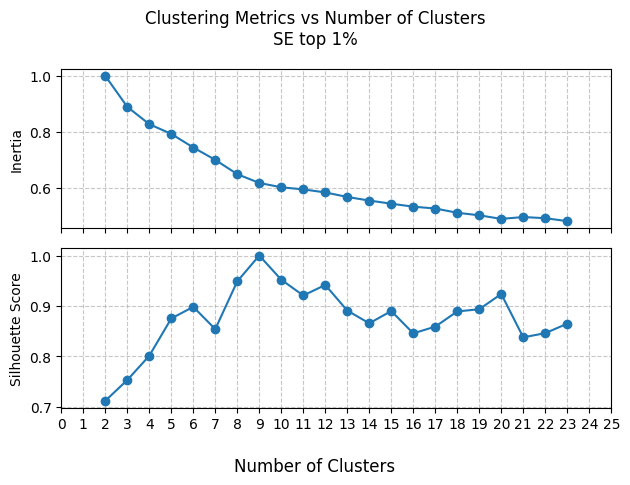

In [13]:
n_clusters = 24
n_top = se_221_dict["weights"].shape[0]
X = se_221_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
se_221_dict["inertias"] = inertias
se_221_dict["silhouette"] = silhouette_scores

subptitle = "SE top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=se_221_dict["inertias"],
    silhouettes=se_221_dict["silhouette"],
    n_clusters=se_221_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse/clustering_221_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse/clustering_221_metrics.jpg")

### PCA

Number of components needed to explain  95.0% variance: 71


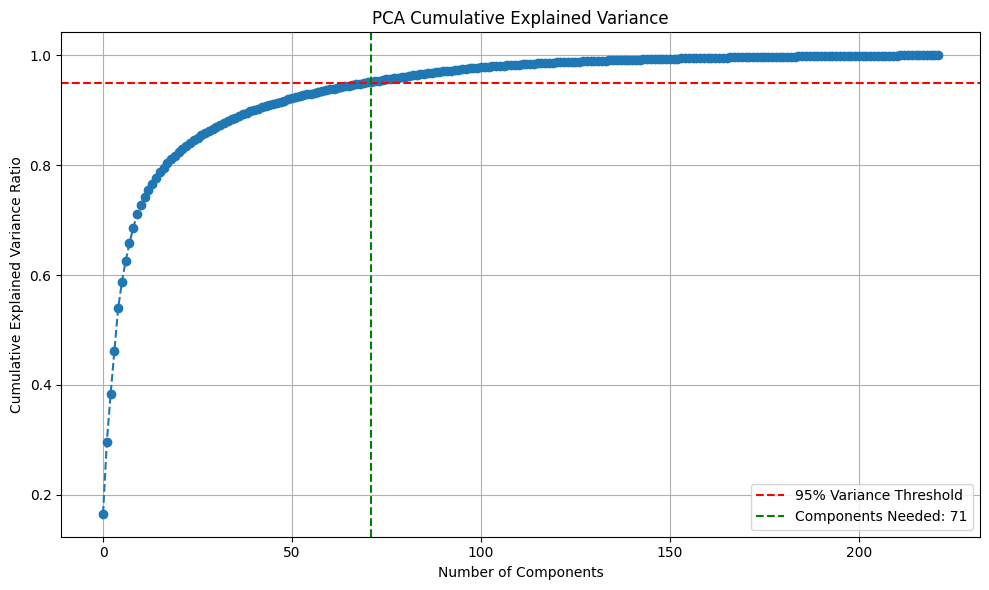

In [14]:
X = se_221_dict["norm_unique_weights"]

variance_threshold = 0.95
n_components, cumvar, X_pca = pca_variance_analysis(X, variance_threshold)

print(
    "Number of components needed to explain "
    f" {variance_threshold*100}% variance: {n_components}"
)

fig, ax = plot_pca_variance(
    cumvar,
    n_components,
    variance_threshold=variance_threshold,
    # figsize=(10, 6),
)

# Filter SE

## Data prep

In [15]:
score_name = "mse_filter_250"

run_ids_filter_se_dict = {
    "110": "xai_202606230202_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606230229_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606230243_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

filter_se_anomalies_arr, filter_se_specobjids_array, filter_se_weights_dict = (
    load_xai_arrs(run_ids_dict=run_ids_filter_se_dict, load_from=load_from)
)

filter_se_110_dict = weights_prep(weights=filter_se_weights_dict["110"], n_segments=110)
filter_se_150_dict = weights_prep(weights=filter_se_weights_dict["150"], n_segments=150)
filter_se_221_dict = weights_prep(weights=filter_se_weights_dict["221"], n_segments=221)

Base size: 34, Residual size: 33
New number of segments: 111
Base size: 25, Residual size: 23
New number of segments: 151
Base size: 17, Residual size: 16
New number of segments: 222


## Culstering 150

Run time: 3.42 seconds


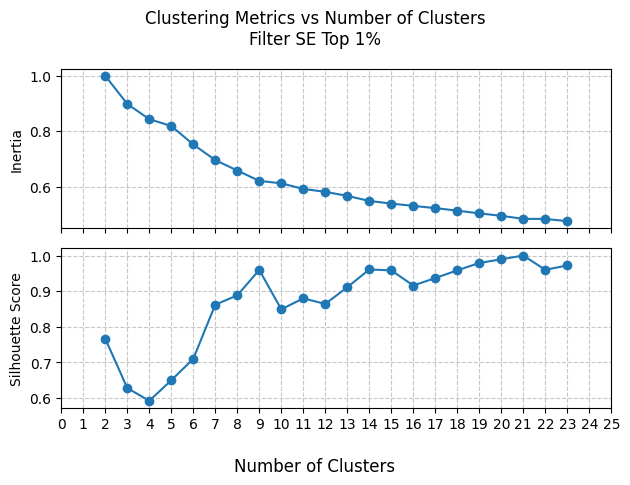

In [16]:
n_clusters = 24
n_top = filter_se_150_dict["weights"].shape[0]
X = filter_se_150_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
filter_se_150_dict["inertias"] = inertias
filter_se_150_dict["silhouette"] = silhouette_scores

subptitle = "Filter SE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=filter_se_150_dict["inertias"],
    silhouettes=filter_se_150_dict["silhouette"],
    n_clusters=filter_se_150_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_filter_250/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_filter_250/clustering_metrics.jpg")

## Clustering 221

Run time: 3.62 seconds


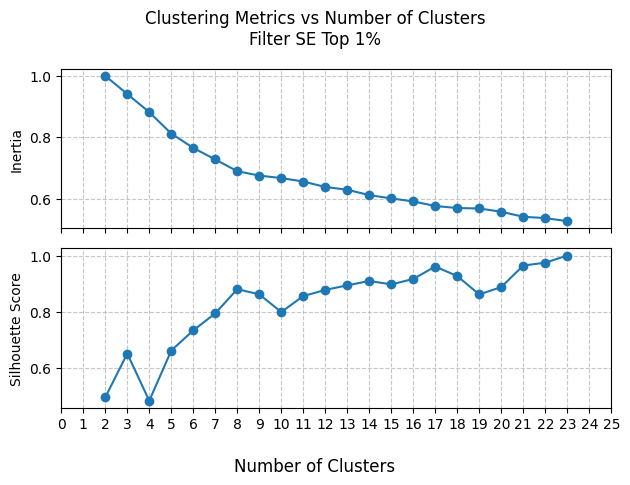

In [18]:
n_clusters = 24
n_top = filter_se_221_dict["weights"].shape[0]
X = filter_se_221_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
filter_se_221_dict["inertias"] = inertias
filter_se_221_dict["silhouette"] = silhouette_scores

subptitle = "Filter SE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=filter_se_221_dict["inertias"],
    silhouettes=filter_se_221_dict["silhouette"],
    n_clusters=filter_se_221_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_filter_250/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_filter_250/clustering_metrics.jpg")

# Trim SE

## Data prep

In [19]:
score_name = "mse_97"

run_ids_trim_se_dict = {
    "110": "xai_202606250039_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606250057_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606250112_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

trim_se_anomalies_arr, trim_se_specobjids_array, trim_se_weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_trim_se_dict, load_from=load_from
)
trim_se_110_dict = weights_prep(weights=trim_se_weights_dict["110"], n_segments=110)
trim_se_150_dict = weights_prep(weights=trim_se_weights_dict["150"], n_segments=150)
trim_se_221_dict = weights_prep(weights=trim_se_weights_dict["221"], n_segments=221)

Base size: 34, Residual size: 33
New number of segments: 111
Base size: 25, Residual size: 23
New number of segments: 151
Base size: 17, Residual size: 16
New number of segments: 222


## Clustering 150

Run time: 3.48 seconds


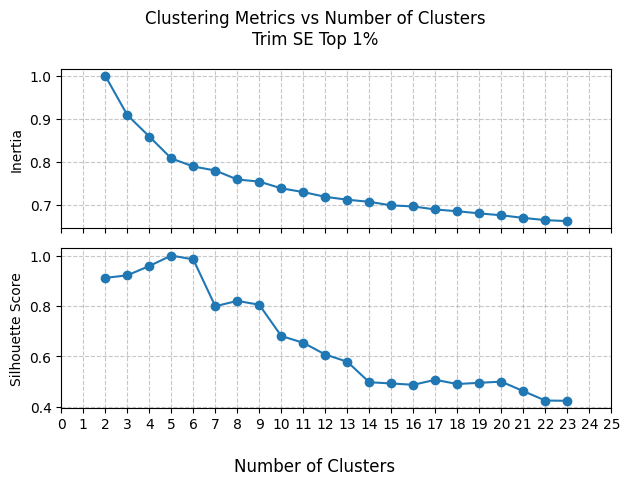

In [20]:
n_clusters = 24
n_top = trim_se_150_dict["weights"].shape[0]
X = trim_se_150_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
trim_se_150_dict["inertias"] = inertias
trim_se_150_dict["silhouette"] = silhouette_scores

subptitle = "Trim SE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=trim_se_150_dict["inertias"],
    silhouettes=trim_se_150_dict["silhouette"],
    n_clusters=trim_se_150_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97/clustering_metrics.jpg")

## Clustering 221

Run time: 3.62 seconds


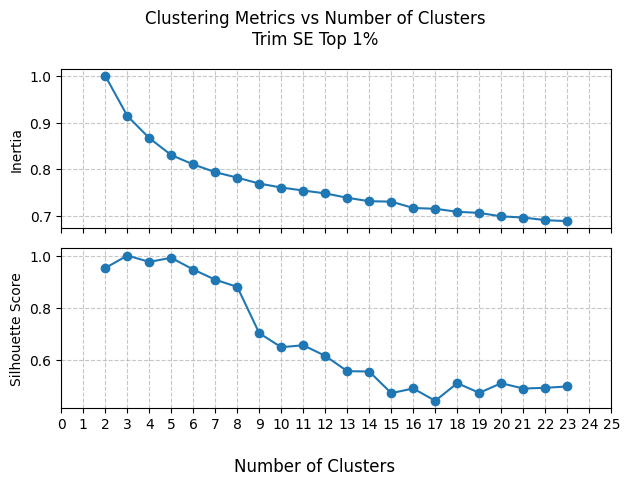

In [21]:
n_clusters = 24
n_top = trim_se_221_dict["weights"].shape[0]
X = trim_se_221_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
trim_se_221_dict["inertias"] = inertias
trim_se_221_dict["silhouette"] = silhouette_scores

subptitle = "Trim SE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=trim_se_221_dict["inertias"],
    silhouettes=trim_se_221_dict["silhouette"],
    n_clusters=trim_se_221_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97/clustering_metrics.jpg")

# RSE

## Data prep

In [22]:
score_name = "mse_rel"

run_ids_rse_dict = {
    "110": "xai_202606231932_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606231944_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606231955_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

(
    rse_anomalies_arr,
    rse_specobjids_array,
    rse_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_rse_dict, load_from=load_from)

rse_110_dict = weights_prep(weights=rse_weights_dict["110"], n_segments=110)
rse_150_dict = weights_prep(weights=rse_weights_dict["150"], n_segments=150)
rse_221_dict = weights_prep(weights=rse_weights_dict["221"], n_segments=221)

Base size: 34, Residual size: 33
New number of segments: 111
Base size: 25, Residual size: 23
New number of segments: 151
Base size: 17, Residual size: 16
New number of segments: 222


## Clustering 150

Run time: 3.42 seconds


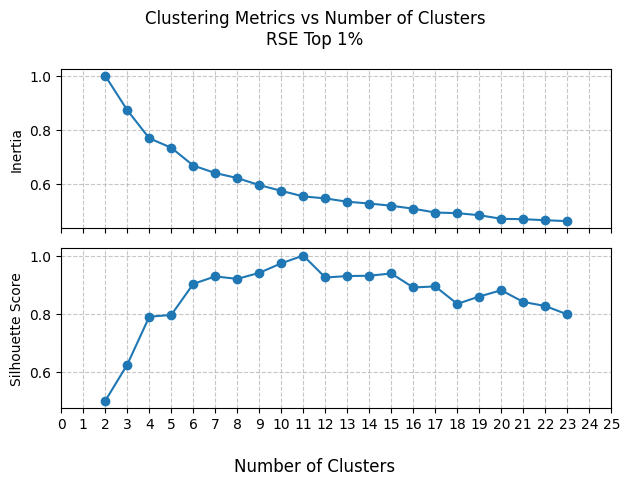

In [23]:
n_clusters = 24
n_top = rse_150_dict["weights"].shape[0]
X = rse_150_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
rse_150_dict["inertias"] = inertias
rse_150_dict["silhouette"] = silhouette_scores

subptitle = "RSE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=rse_150_dict["inertias"],
    silhouettes=rse_150_dict["silhouette"],
    n_clusters=rse_150_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_rel/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_rel/clustering_metrics.jpg")

## Clustering 221

Run time: 3.62 seconds


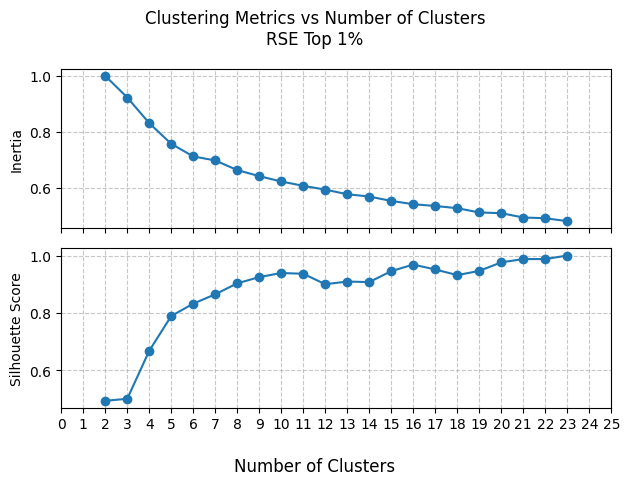

In [24]:
n_clusters = 24
n_top = rse_221_dict["weights"].shape[0]
X = rse_221_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
rse_221_dict["inertias"] = inertias
rse_221_dict["silhouette"] = silhouette_scores

subptitle = "RSE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=rse_221_dict["inertias"],
    silhouettes=rse_221_dict["silhouette"],
    n_clusters=rse_221_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97/clustering_metrics.jpg")

# Trim RSE

## Data prep

In [25]:
score_name = "mse_97_rel"

run_ids_trim_rse_dict = {
    "110": "xai_202606250127_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606250146_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606250203_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

(
    trim_rse_anomalies_arr,
    trim_rse_specobjids_array,
    trim_rse_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_trim_rse_dict, load_from=load_from)

trim_rse_110_dict = weights_prep(weights=trim_rse_weights_dict["110"], n_segments=110)
trim_rse_150_dict = weights_prep(weights=trim_rse_weights_dict["150"], n_segments=150)
trim_rse_221_dict = weights_prep(weights=trim_rse_weights_dict["221"], n_segments=221)

Base size: 34, Residual size: 33
New number of segments: 111
Base size: 25, Residual size: 23
New number of segments: 151
Base size: 17, Residual size: 16
New number of segments: 222


## Clustering 150

Run time: 3.55 seconds


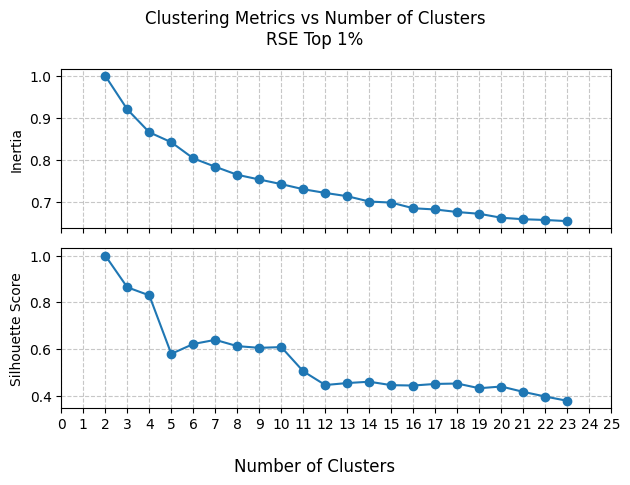

In [26]:
n_clusters = 24
n_top = trim_rse_150_dict["weights"].shape[0]
X = trim_rse_150_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
trim_rse_150_dict["inertias"] = inertias
trim_rse_150_dict["silhouette"] = silhouette_scores

subptitle = "RSE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=trim_rse_150_dict["inertias"],
    silhouettes=trim_rse_150_dict["silhouette"],
    n_clusters=trim_rse_150_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97_rel/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97_rel/clustering_metrics.jpg")

## Clustering 221

Run time: 3.62 seconds


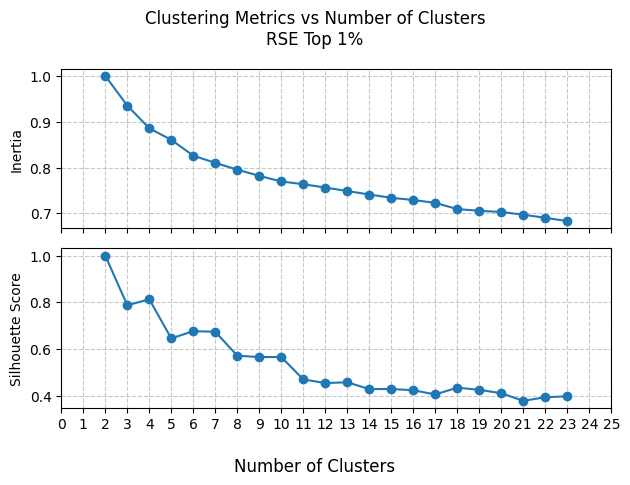

In [27]:
n_clusters = 24
n_top = trim_rse_221_dict["weights"].shape[0]
X = trim_rse_221_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
trim_rse_221_dict["inertias"] = inertias
trim_rse_221_dict["silhouette"] = silhouette_scores

subptitle = "RSE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=trim_rse_221_dict["inertias"],
    silhouettes=trim_rse_221_dict["silhouette"],
    n_clusters=trim_rse_221_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97_rel/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/mse_97_rel/clustering_metrics.jpg")

# iForest

## Data prep

In [28]:
score_name = "iforest"

run_ids_iforest_dict = {
    "110": "xai_202606211509_uniform_110_samples_50000_scale_0.9",
    "150": "xai_202606211622_uniform_150_samples_50000_scale_0.9",
    "221": "xai_202606222135_uniform_221_samples_50000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

(
    iforest_anomalies_arr,
    iforest_specobjids_array,
    iforest_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_iforest_dict, load_from=load_from)

iforest_110_dict = weights_prep(weights=iforest_weights_dict["110"], n_segments=110)
iforest_150_dict = weights_prep(weights=iforest_weights_dict["150"], n_segments=150)
iforest_221_dict = weights_prep(weights=iforest_weights_dict["221"], n_segments=221)

Base size: 34, Residual size: 33
New number of segments: 111
Base size: 25, Residual size: 23
New number of segments: 151
Base size: 17, Residual size: 16
New number of segments: 222


## Clustering 150

Run time: 3.65 seconds


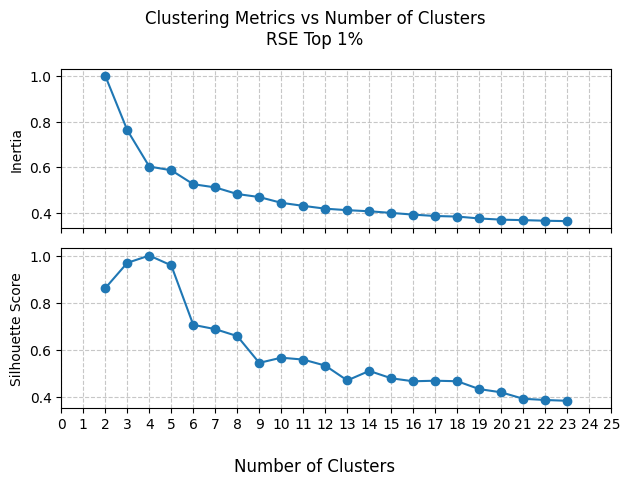

In [29]:
n_clusters = 24
n_top = iforest_150_dict["weights"].shape[0]
X = iforest_150_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
iforest_150_dict["inertias"] = inertias
iforest_150_dict["silhouette"] = silhouette_scores

subptitle = "RSE Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=iforest_150_dict["inertias"],
    silhouettes=iforest_150_dict["silhouette"],
    n_clusters=iforest_150_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/iforest/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/iforest/clustering_metrics.jpg")

## Clustering 221

Run time: 3.92 seconds


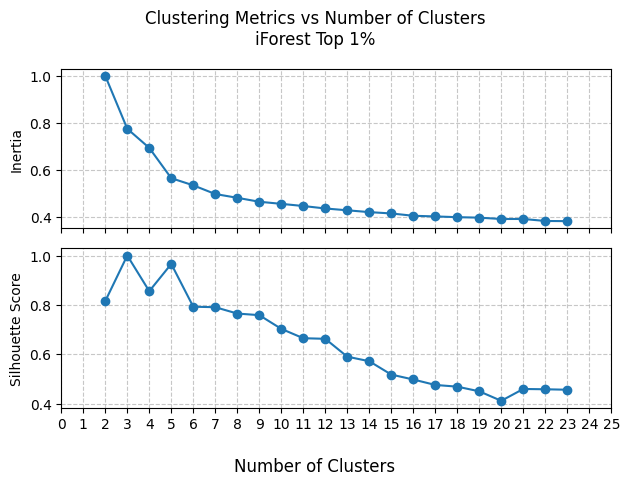

In [30]:
n_clusters = 24
n_top = iforest_221_dict["weights"].shape[0]
X = iforest_221_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
iforest_221_dict["inertias"] = inertias
iforest_221_dict["silhouette"] = silhouette_scores

subptitle = "iForest Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=iforest_221_dict["inertias"],
    silhouettes=iforest_221_dict["silhouette"],
    n_clusters=iforest_221_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/iforest/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/iforest/clustering_metrics.jpg")

# LOF

## Data prep

In [31]:
score_name = "lof"

run_ids_lof_dict = {
    "110": "xai_202606211703_uniform_110_samples_50000_scale_0.9",
    "150": "xai_202606212335_uniform_150_samples_50000_scale_0.9",
    "221": "xai_202606221052_uniform_221_samples_50000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}"

(
    lof_anomalies_arr,
    lof_specobjids_array,
    lof_weights_dict,
) = load_xai_arrs(run_ids_dict=run_ids_lof_dict, load_from=load_from)

lof_110_dict = weights_prep(weights=lof_weights_dict["110"], n_segments=110)
lof_150_dict = weights_prep(weights=lof_weights_dict["150"], n_segments=150)
lof_221_dict = weights_prep(weights=lof_weights_dict["221"], n_segments=221)

Base size: 34, Residual size: 33
New number of segments: 111
Base size: 25, Residual size: 23
New number of segments: 151
Base size: 17, Residual size: 16
New number of segments: 222


## Clustering 150

Run time: 3.58 seconds


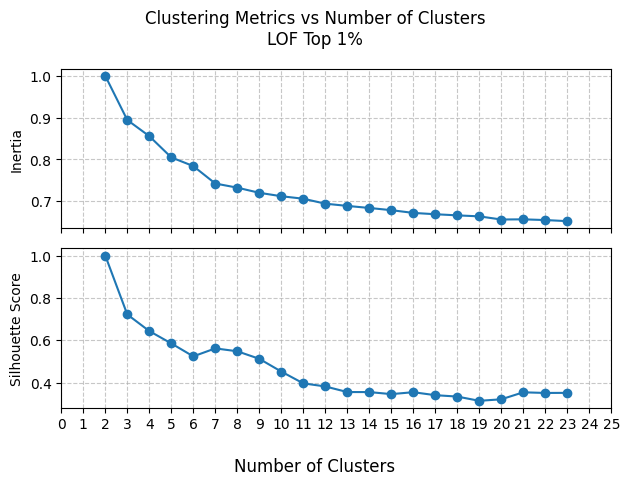

In [32]:
n_clusters = 24
n_top = lof_150_dict["weights"].shape[0]
X = lof_150_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
lof_150_dict["inertias"] = inertias
lof_150_dict["silhouette"] = silhouette_scores

subptitle = "LOF Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=lof_150_dict["inertias"],
    silhouettes=lof_150_dict["silhouette"],
    n_clusters=lof_150_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/lof/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/lof/clustering_metrics.jpg")

## Clustering 221

Run time: 3.70 seconds


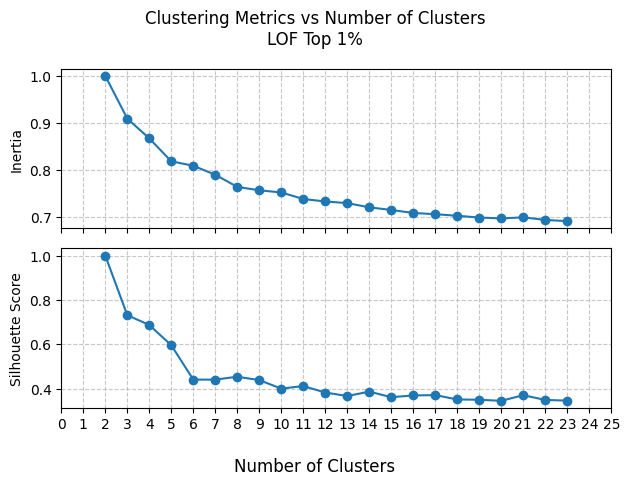

In [33]:
n_clusters = 24
n_top = lof_221_dict["weights"].shape[0]
X = lof_221_dict["norm_unique_weights"]

inertias, silhouette_scores = clustering.compute_inertias_silhouette(
    X=X, n_clusters=n_clusters
)

inertias /= np.max(inertias)
silhouette_scores /= np.max(silhouette_scores)
lof_221_dict["inertias"] = inertias
lof_221_dict["silhouette"] = silhouette_scores

subptitle = "LOF Top 1%"
fig, axs = plot_inertias_silhouettes(
    inertias=lof_221_dict["inertias"],
    silhouettes=lof_221_dict["silhouette"],
    n_clusters=lof_221_dict["inertias"].shape[0] + 2,
    subtitle=subptitle,
)

plt.tight_layout()

# fig.savefig(f"{clustering_dir}/{bin_id}/lof/clustering_metrics.pdf")
# fig.savefig(f"{clustering_dir}/{bin_id}/lof/clustering_metrics.jpg")